In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir) 

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
import bcosgnn
import torch
import torch_geometric
import functools
import itertools
import operator
from pathlib import Path
from typing import Any
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
import torch.nn as nn
from torch_geometric.nn import GINConv, global_mean_pool, global_add_pool
from sklearn.metrics import f1_score, accuracy_score

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def _augment_with_normalized_pos(dataset):
    augmented = []
    for data in dataset:
        d = data.clone()
        pos = d.pos.float()
        pos_min = pos.min(dim=0).values
        pos_max = pos.max(dim=0).values
        denom = (pos_max - pos_min).clamp(min=1e-8)
        pos_norm = (pos - pos_min) / denom
        d.x = torch.cat([d.x.float(), pos_norm], dim=-1)
        augmented.append(d)
    return augmented


def load_and_split_data(batch_size=64, add_pos_features=True):
    print("Loading preprocessed sparsified .pt splits...")

    candidate_roots = [
        project_root / 'data' / 'MNIST' / 'sparsified_pt_splits',
        project_root / 'shaique_updates' / 'codes' / 'MNISTsp' / 'data' / 'MNIST' / 'sparsified_pt_splits',
    ]

    split_root = None
    for root in candidate_roots:
        if (root / 'train_sparsified.pt').exists() and (root / 'val_sparsified.pt').exists() and (root / 'test_sparsified.pt').exists():
            split_root = root
            break

    if split_root is None:
        raise FileNotFoundError(
            "Could not find saved sparsified split files. "
            "Expected train/val/test_sparsified.pt in one of the candidate directories."
        )

    train_path = split_root / 'train_sparsified.pt'
    val_path = split_root / 'val_sparsified.pt'
    test_path = split_root / 'test_sparsified.pt'

    train_dataset = torch.load(train_path, map_location='cpu', weights_only=False)
    val_dataset = torch.load(val_path, map_location='cpu', weights_only=False)
    test_dataset = torch.load(test_path, map_location='cpu', weights_only=False)

    if add_pos_features:
        train_dataset = _augment_with_normalized_pos(train_dataset)
        val_dataset = _augment_with_normalized_pos(val_dataset)
        test_dataset = _augment_with_normalized_pos(test_dataset)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_labels = torch.tensor([int(d.y.item()) for d in train_dataset + val_dataset + test_dataset])
    num_classes = int(all_labels.unique().numel())
    num_node_features = int(train_dataset[0].num_node_features)
    avg_train_edges = float(np.mean([int(d.edge_index.size(1)) for d in train_dataset[:1000]]))

    dataset_info = {
        'num_node_features': num_node_features,
        'num_classes': num_classes,
        'num_edge_features': int(train_dataset[0].edge_attr.size(-1)) if train_dataset[0].edge_attr is not None else 0
    }

    print(f"Using split directory: {split_root}")
    print(
        f"Loaded splits. Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}"
    )
    print(f"Avg train edges (first 1000 graphs): {avg_train_edges:.2f}")
    print(f"Node features: {num_node_features} (pos features added: {add_pos_features})")

    return train_loader, val_loader, test_loader, dataset_info

# Dataset stats

In [4]:
train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=64)

print(f"Dataset info: {dataset_info}")

Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Dataset info: {'num_node_features': 3, 'num_classes': 10, 'num_edge_features': 0}
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Dataset info: {'num_node_features': 3, 'num_classes': 10, 'num_edge_features': 0}


## Vanilla GIN Model

In [13]:
class GIN(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4):
        super().__init__()

        self.node_encoder = nn.Linear(in_channels, hidden_channels)
        self.message_passing = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels),
            )
            self.message_passing.append(GINConv(nn=mlp, train_eps=True))

        self.global_pool = SumAggregation()
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.node_encoder(x))
        for conv in self.message_passing:
            x = conv(x, edge_index)
            x = F.relu(x)

        graph_embedding = self.global_pool(x, batch)
        out = self.classifier(graph_embedding)
        return out

In [14]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data in tqdm(loader, desc="Training", leave=False):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in tqdm(loader, desc="Evaluating", leave=False):
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs

            pred = torch.argmax(out, dim=1)
            all_preds.append(pred.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(np.concatenate(all_labels), np.concatenate(all_preds))
    f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average='weighted')

    return avg_loss, acc, f1

In [6]:
def main():
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    print(f"Using device: {device}")

    train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=64)

    model = GIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=64,
        out_channels=dataset_info['num_classes'],
        num_layers=4
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    epochs = 30
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    print("Starting training...")
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}"
        )

    print("Evaluating on test set...")
    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")


if __name__ == "__main__":
    main()

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 532.30
Node features: 3 (pos features added: True)
Starting training...


Epoch 001, Train Loss: 1.5240, Val Loss: 1.3619, Val Acc: 0.4972, Val F1: 0.4638, LR: 0.000997


Epoch 002, Train Loss: 1.0719, Val Loss: 1.7185, Val Acc: 0.4750, Val F1: 0.4668, LR: 0.000989


Epoch 003, Train Loss: 0.8759, Val Loss: 0.8833, Val Acc: 0.6958, Val F1: 0.6828, LR: 0.000976


Epoch 004, Train Loss: 0.7824, Val Loss: 1.3788, Val Acc: 0.5568, Val F1: 0.5578, LR: 0.000957


...

Epoch 027, Train Loss: 0.3057, Val Loss: 0.3822, Val Acc: 0.8802, Val F1: 0.8800, LR: 0.000025


Epoch 028, Train Loss: 0.2989, Val Loss: 0.3850, Val Acc: 0.8772, Val F1: 0.8771, LR: 0.000012


Epoch 029, Train Loss: 0.2952, Val Loss: 0.3827, Val Acc: 0.8792, Val F1: 0.8793, LR: 0.000004


Epoch 030, Train Loss: 0.2959, Val Loss: 0.3840, Val Acc: 0.8784, Val F1: 0.8786, LR: 0.000001
Evaluating on test set...


Test Loss: 0.3604, Test Acc: 0.8900, Test F1: 0.8904


In [12]:
# Quick sanity check (no full training)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=32)

model = GIN(
    in_channels=dataset_info['num_node_features'],
    hidden_channels=64,
    out_channels=dataset_info['num_classes'],
    num_layers=4
).to(device)

batch = next(iter(train_loader)).to(device)
with torch.no_grad():
    logits = model(batch.x, batch.edge_index, batch.batch)

print('Sanity check passed.')
print('Batch graphs:', batch.num_graphs)
print('Logits shape:', tuple(logits.shape))

Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Sanity check passed.
Batch graphs: 32
Logits shape: (32, 10)
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Sanity check passed.
Batch graphs: 32
Logits shape: (32, 10)


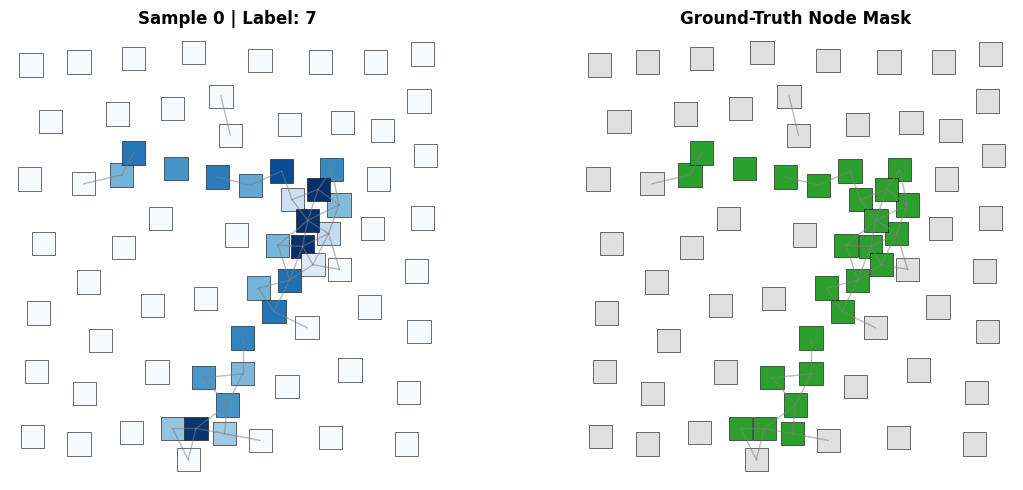

Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Label: 7 | Nodes: 75 | Edges: 83
GT mask positives: 25/75


In [14]:
# Visualization for explanation comparison: graph + label + GT node mask
import matplotlib.pyplot as plt
from pathlib import Path

candidate_roots = [
    project_root / 'data' / 'MNIST' / 'sparsified_pt_splits',
    project_root / 'shaique_updates' / 'codes' / 'MNISTsp' / 'data' / 'MNIST' / 'sparsified_pt_splits',
]

split_root = None
for root in candidate_roots:
    if (root / 'test_sparsified.pt').exists():
        split_root = root
        break

if split_root is None:
    raise FileNotFoundError('Could not find saved sparsified test split (.pt).')

test_dataset = torch.load(split_root / 'test_sparsified.pt', map_location='cpu', weights_only=False)

sample_idx = 0
graph_data = test_dataset[sample_idx]

if not hasattr(graph_data, 'node_mask') or graph_data.node_mask is None:
    raise ValueError('Ground-truth node mask not found in saved sample.')

x_coords = graph_data.pos[:, 0].cpu().numpy()
y_coords = graph_data.pos[:, 1].cpu().numpy()
row, col = graph_data.edge_index

intensity = graph_data.x[:, 0].cpu().numpy()
gt_mask = graph_data.node_mask.cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(graph_data.num_edges):
    s = graph_data.pos[row[i]].cpu().numpy()
    e = graph_data.pos[col[i]].cpu().numpy()
    ax1.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1)
    ax2.plot([s[0], e[0]], [s[1], e[1]], color='gray', alpha=0.3, linewidth=1)

ax1.scatter(
    x_coords, y_coords, c=intensity, cmap='Blues',
    marker='s', s=280, edgecolor='black', linewidth=0.4
)
ax1.invert_yaxis()
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title(f'Sample {sample_idx} | Label: {int(graph_data.y.item())}', fontweight='bold')

cmap_binary = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
ax2.scatter(
    x_coords, y_coords, c=gt_mask, cmap=cmap_binary,
    marker='s', s=280, edgecolor='black', linewidth=0.4, vmin=0, vmax=1
)
ax2.invert_yaxis()
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Ground-Truth Node Mask', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Using split directory: {split_root}')
print(f'Label: {int(graph_data.y.item())} | Nodes: {graph_data.num_nodes} | Edges: {graph_data.num_edges}')
print(f'GT mask positives: {int(graph_data.node_mask.sum().item())}/{graph_data.num_nodes}')

## BCos GIN + GT Mask Evaluation

In [7]:
from sklearn.metrics import roc_auc_score

class BcosGINConv(MessagePassing):
    def __init__(self, channels, b=2, max_out=1, eps=0.0, train_eps=False, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        if train_eps:
            self.eps = torch.nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer('eps', torch.tensor([eps], dtype=torch.float))

    def forward(self, x, edge_index):
        x_res = x
        out = self.propagate(edge_index, x=x)
        out = (1 + self.eps) * x_res + out
        return self.transform(out)

    def message(self, x_j):
        return x_j


In [8]:
import torch
from torch_geometric.nn import SumAggregation

class BCosGIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4, b=2, max_out=1):
        super().__init__()
        
        # ==========================================
        # PHASE 1: Initial Node Encoding
        # Maps raw input features to the hidden dimension
        # ==========================================
        self.node_encoder = BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out)
        
        # ==========================================
        # PHASE 2: Message Passing Layers (Vanilla GIN Skeleton)
        # Uses a 2-layer expansive MLP inside the convolution
        # ==========================================
        self.message_passing = torch.nn.ModuleList()
        for _ in range(num_layers):
            # Expansive MLP: hidden -> 2*hidden -> hidden
            mlp_channels = [hidden_channels, hidden_channels]
            
            layer = BcosGINConv(
                channels=mlp_channels, 
                b=b, 
                max_out=max_out, 
                train_eps=True
            )
            self.message_passing.append(layer)
            
        # ==========================================
        # PHASE 3: Global Graph Pooling
        # Condenses node features into a single graph vector
        # Using SumAggregation as explicitly requested
        # ==========================================
        self.global_pool = SumAggregation()
        
        # ==========================================
        # PHASE 4: Readout / Classifier (Vanilla GIN Skeleton)
        # Uses a narrowing bottleneck before final output
        # ==========================================
        self.classifier = BcosSequential(
            BcosLinear(hidden_channels, out_channels, b=b, max_out=max_out),
        )

    def forward(self, x, edge_index, batch):
        # 1. Encode nodes
        x = self.node_encoder(x)
        
        # 2. Pass messages across edges
        for conv in self.message_passing:
            x = conv(x, edge_index)
            # (No explicit ReLU here, BCos handles non-linearity via max_out)
            
        # 3. Pool the graph into a single vector
        graph_embedding = self.global_pool(x, batch)
        
        # 4. Predict the final classes
        out = self.classifier(graph_embedding)
        
        return out

In [9]:

def train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    scheduler_type=None,       # Changed: 'cosine', 'plateau', or None
    plateau_factor=0.5,        # Added: Factor by which LR is reduced
    plateau_patience=10,       # Added: Epochs to wait before dropping LR
    early_stopping=True,
    patience=15,
    min_delta=0.0,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=batch_size, add_pos_features=True)

    model = BCosGIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=hidden_channels,
        out_channels=dataset_info['num_classes'],
        num_layers=num_layers,
        b=2.5,
        max_out=1,
    ).to(device)

    # Simplified the learning rate assignment
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Initialize the selected scheduler
    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=plateau_factor, patience=plateau_patience)
    else:
        scheduler = None

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    print('Starting BCos GIN training...')
    print(
        f'Config -> epochs={epochs}, batch_size={batch_size}, hidden={hidden_channels}, layers={num_layers}, '
        f'scheduler_type={scheduler_type}, lr={lr}, early_stopping={early_stopping}, patience={patience}'
    )

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        # Apply the scheduler step properly based on its type
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss) # Plateau needs to see the validation loss
            else:
                scheduler.step()         # Cosine steps blindly

        current_lr = optimizer.param_groups[0]['lr']

        improved = val_loss < (best_val_loss - min_delta)
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f'[BCOS] Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}'
        )

        if early_stopping and wait >= patience:
            print(f'[BCOS] Early stopping at epoch {epoch} (no val loss improvement for {patience} epochs).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f'[BCOS] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    return model, train_loader, val_loader, test_loader


def get_bcos_node_scores(model, data):
    model_device = next(model.parameters()).device
    data = data.to(model_device)
    batch = torch.zeros(data.x.size(0), dtype=torch.long, device=model_device)

    node_contrib = explain(model, data.x, data.edge_index, batch).detach()
    node_scores = node_contrib.abs().sum(dim=1).cpu().numpy()
    gt_mask = data.node_mask.detach().cpu().numpy().reshape(-1).astype(int)

    return node_scores, gt_mask


def evaluate_bcos_explanations(model, dataset, max_graphs=None):
    jaccards = []
    aurocs = []
    n = len(dataset) if max_graphs is None else min(len(dataset), max_graphs)

    for idx in range(n):
        data = dataset[idx].clone()
        if not hasattr(data, 'node_mask') or data.node_mask is None:
            continue

        scores, gt = get_bcos_node_scores(model, data)
        k = int(gt.sum())
        if k <= 0:
            continue

        top_k = np.argsort(scores)[-k:]
        pred = np.zeros_like(gt)
        pred[top_k] = 1

        intersection = np.logical_and(gt == 1, pred == 1).sum()
        union = np.logical_or(gt == 1, pred == 1).sum()
        jaccard = float(intersection / union) if union > 0 else 0.0
        jaccards.append(jaccard)

        if gt.min() != gt.max():
            aurocs.append(float(roc_auc_score(gt, scores)))

    mean_jacc = float(np.mean(jaccards)) if len(jaccards) else float('nan')
    mean_auroc = float(np.mean(aurocs)) if len(aurocs) else float('nan')

    print(f'[BCOS Explain] Graphs evaluated: {n}')
    print(f'[BCOS Explain] Mean Jaccard: {mean_jacc:.4f}')
    print(f'[BCOS Explain] Mean AUROC: {mean_auroc:.4f}')

    return {'jaccard': mean_jacc, 'auroc': mean_auroc, 'num_graphs': n}

In [34]:
# Run BCos-GIN with scheduler OFF and fixed LR, with early stopping
bcos_model, bcos_train_loader, bcos_val_loader, bcos_test_loader = train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    scheduler_type='plateau',  # Using ReduceLROnPlateau scheduler
    plateau_factor=0.5,
    plateau_patience=10,
    #fixed_lr=None,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 )

# Evaluate explanation quality on the entire test set
bcos_metrics = evaluate_bcos_explanations(
    bcos_model,
    bcos_test_loader.dataset,
    max_graphs=None,
 )

print('BCos explanation metrics:', bcos_metrics)

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=plateau, lr=0.001, early_stopping=True, patience=15


[BCOS] Epoch 001, Train Loss: 2.0291, Val Loss: 1.8887, Val Acc: 0.3244, Val F1: 0.2623, LR: 0.001000


[BCOS] Epoch 002, Train Loss: 1.7875, Val Loss: 1.6516, Val Acc: 0.4392, Val F1: 0.4159, LR: 0.001000


[BCOS] Epoch 003, Train Loss: 1.6105, Val Loss: 1.5565, Val Acc: 0.4908, Val F1: 0.4809, LR: 0.001000


[BCOS] Epoch 004, Train Loss: 1.5043, Val Loss: 1.4256, Val Acc: 0.5200, Val F1: 0.5058, LR: 0.001000


...

[BCOS] Epoch 097, Train Loss: 0.7225, Val Loss: 0.8123, Val Acc: 0.7284, Val F1: 0.7270, LR: 0.001000


[BCOS] Epoch 098, Train Loss: 0.7185, Val Loss: 0.7680, Val Acc: 0.7426, Val F1: 0.7403, LR: 0.001000


[BCOS] Epoch 099, Train Loss: 0.7149, Val Loss: 0.7944, Val Acc: 0.7380, Val F1: 0.7365, LR: 0.001000


[BCOS] Epoch 100, Train Loss: 0.7188, Val Loss: 0.7861, Val Acc: 0.7370, Val F1: 0.7345, LR: 0.001000


[BCOS] Test Loss: 0.7658, Test Acc: 0.7500, Test F1: 0.7492
[BCOS Explain] Graphs evaluated: 1000
[BCOS Explain] Mean Jaccard: 0.5026
[BCOS Explain] Mean AUROC: 0.7895
BCos explanation metrics: {'jaccard': 0.5026226277270784, 'auroc': 0.789508, 'num_graphs': 1000}


In [31]:
# Run BCos-GIN with scheduler OFF and fixed LR, with early stopping
bcos_model, bcos_train_loader, bcos_val_loader, bcos_test_loader = train_bcos_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    scheduler_type='cosine',  # Using CosineAnnealingLR scheduler
    #plateau_factor=0.5,
    #plateau_patience=10,
    #fixed_lr=None,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 )

# Evaluate explanation quality on the entire test set
bcos_metrics = evaluate_bcos_explanations(
    bcos_model,
    bcos_test_loader.dataset,
    max_graphs=None,
 )

print('BCos explanation metrics:', bcos_metrics)

Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=cosine, lr=0.001, early_stopping=True, patience=15


[BCOS] Epoch 001, Train Loss: 2.0882, Val Loss: 2.0282, Val Acc: 0.2408, Val F1: 0.1671, LR: 0.001000


[BCOS] Epoch 002, Train Loss: 2.0246, Val Loss: 2.0334, Val Acc: 0.2258, Val F1: 0.1498, LR: 0.000999


[BCOS] Epoch 003, Train Loss: 2.0079, Val Loss: 2.0682, Val Acc: 0.2150, Val F1: 0.1324, LR: 0.000998


[BCOS] Epoch 004, Train Loss: 1.9939, Val Loss: 1.9374, Val Acc: 0.2856, Val F1: 0.2433, LR: 0.000996


...

[BCOS] Epoch 097, Train Loss: 0.4980, Val Loss: 0.6329, Val Acc: 0.7974, Val F1: 0.7977, LR: 0.000003


[BCOS] Epoch 098, Train Loss: 0.4976, Val Loss: 0.6310, Val Acc: 0.7968, Val F1: 0.7968, LR: 0.000002


[BCOS] Epoch 099, Train Loss: 0.4973, Val Loss: 0.6312, Val Acc: 0.7974, Val F1: 0.7975, LR: 0.000001


[BCOS] Epoch 100, Train Loss: 0.4970, Val Loss: 0.6311, Val Acc: 0.7978, Val F1: 0.7979, LR: 0.000001


[BCOS] Test Loss: 0.6298, Test Acc: 0.7880, Test F1: 0.7886
[BCOS Explain] Graphs evaluated: 1000
[BCOS Explain] Mean Jaccard: 0.7647
[BCOS Explain] Mean AUROC: 0.9491
BCos explanation metrics: {'jaccard': 0.7647012623403004, 'auroc': 0.9491128000000001, 'num_graphs': 1000}


## Timing Experiments (Vanilla vs BCos)

In [10]:
import time
import random
from copy import deepcopy

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def benchmark_test_inference_total(model, test_loader, device):
    model.eval()
    _sync_if_cuda()
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            _ = model(batch.x, batch.edge_index, batch.batch)
    _sync_if_cuda()
    return time.perf_counter() - t0

def time_bcos_explanations(model, dataset, warmup=2):
    model.eval()
    times_ms = []
    graphs = dataset

    for data in graphs[:warmup]:
        _ = get_bcos_node_scores(model, data)

    for data in graphs:
        _sync_if_cuda()
        start = time.perf_counter()
        _ = get_bcos_node_scores(model, data)
        _sync_if_cuda()
        end = time.perf_counter()
        times_ms.append((end - start) * 1000.0)

    arr = np.asarray(times_ms, dtype=float)
    mean_ms = float(arr.mean()) if arr.size else float("nan")
    median_ms = float(np.median(arr)) if arr.size else float("nan")
    p90_ms = float(np.percentile(arr, 90)) if arr.size else float("nan")
    total_s = float(arr.sum() / 1000.0) if arr.size else float("nan")
    graphs_per_s = float(1000.0 / mean_ms) if mean_ms > 0 else float("nan")
    return {
        "mean_ms": mean_ms,
        "median_ms": median_ms,
        "p90_ms": p90_ms,
        "total_s": total_s,
        "graphs_per_s": graphs_per_s,
        "n_graphs": int(arr.size),
    }

def train_vanilla_gin(
    epochs=100,
    batch_size=64,
    lr=1e-3,
    hidden_channels=64,
    num_layers=4,
    scheduler_type="cosine",
    plateau_factor=0.5,
    plateau_patience=10,
    early_stopping=True,
    patience=15,
    min_delta=0.0,
 ):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    train_loader, val_loader, test_loader, dataset_info = load_and_split_data(batch_size=batch_size, add_pos_features=True)

    model = GIN(
        in_channels=dataset_info['num_node_features'],
        hidden_channels=hidden_channels,
        out_channels=dataset_info['num_classes'],
        num_layers=num_layers,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=plateau_factor, patience=plateau_patience)
    else:
        scheduler = None

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    print('Starting Vanilla GIN training...')
    print(
        f'Config -> epochs={epochs}, batch_size={batch_size}, hidden={hidden_channels}, layers={num_layers}, '
        f'scheduler_type={scheduler_type}, lr={lr}, early_stopping={early_stopping}, patience={patience}'
    )

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']

        improved = val_loss < (best_val_loss - min_delta)
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f'[VANILLA] Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}'
        )

        if early_stopping and wait >= patience:
            print(f'[VANILLA] Early stopping at epoch {epoch} (no val loss improvement for {patience} epochs).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f'[VANILLA] Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    return model, train_loader, val_loader, test_loader

def run_multi_seed_vanilla_experiment(
    seeds=(11, 22, 33),
    epochs=100,
    early_stop_patience=15,
 ):
    per_seed = []

    for seed in seeds:
        print(f"\n=== Vanilla Seed {seed} ===")
        set_all_seeds(seed)

        _sync_if_cuda()
        train_start = time.perf_counter()
        model, train_loader, val_loader, test_loader = train_vanilla_gin(
            epochs=epochs,
            batch_size=64,
            lr=1e-3,
            hidden_channels=64,
            num_layers=4,
            scheduler_type='cosine',
            early_stopping=True,
            patience=early_stop_patience,
        )
        _sync_if_cuda()
        train_time_s = time.perf_counter() - train_start

        device = next(model.parameters()).device
        test_loss, test_acc, test_f1 = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
        test_process_total_s = benchmark_test_inference_total(model, test_loader, device)

        row = {
            "seed": seed,
            "test_acc": test_acc,
            "test_f1": test_f1,
            "train_time_s": train_time_s,
            "test_process_total_s": test_process_total_s,
        }
        per_seed.append(row)

        print(
            f"Seed {seed} | Test Acc {test_acc:.4f} | Test F1 {test_f1:.4f} | "
            f"Train {train_time_s:.2f}s | TestProc {test_process_total_s:.2f}s"
        )

    print("\n" + "=" * 72)
    print("VANILLA MULTI-SEED SUMMARY (mean ± std)")
    print("=" * 72)
    for metric in ["test_acc", "test_f1", "train_time_s", "test_process_total_s"]:
        vals = np.array([row[metric] for row in per_seed], dtype=float)
        print(f"{metric:20s}: {vals.mean():.4f} ± {vals.std():.4f}")

    return per_seed

def run_multi_seed_bcos_experiment(
    seeds=(11, 22, 33),
    epochs=100,
    early_stop_patience=15,
 ):
    per_seed = []

    for seed in seeds:
        print(f"\n=== BCos Seed {seed} ===")
        set_all_seeds(seed)

        _sync_if_cuda()
        train_start = time.perf_counter()
        model, train_loader, val_loader, test_loader = train_bcos_gin(
            epochs=epochs,
            batch_size=64,
            lr=1e-3,
            hidden_channels=64,
            num_layers=4,
            scheduler_type='cosine',
            early_stopping=True,
            patience=early_stop_patience,
        )
        _sync_if_cuda()
        train_time_s = time.perf_counter() - train_start

        device = next(model.parameters()).device
        test_loss, test_acc, test_f1 = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
        test_process_total_s = benchmark_test_inference_total(model, test_loader, device)
        explain_timing = time_bcos_explanations(model, test_loader.dataset, warmup=2)

        row = {
            "seed": seed,
            "test_acc": test_acc,
            "test_f1": test_f1,
            "train_time_s": train_time_s,
            "test_process_total_s": test_process_total_s,
            "bcos_explain_total_s": explain_timing["total_s"],
            "bcos_mean_ms": explain_timing["mean_ms"],
            "bcos_median_ms": explain_timing["median_ms"],
            "bcos_p90_ms": explain_timing["p90_ms"],
            "bcos_graphs_per_s": explain_timing["graphs_per_s"],
            "n_graphs": explain_timing["n_graphs"],
        }
        per_seed.append(row)

        print(
            f"Seed {seed} | Test Acc {test_acc:.4f} | Test F1 {test_f1:.4f} | "
            f"Train {train_time_s:.2f}s | TestProc {test_process_total_s:.2f}s | "
            f"BCosExplain {explain_timing['total_s']:.2f}s ({explain_timing['mean_ms']:.2f} ms/graph)"
        )

    print("\n" + "=" * 88)
    print("BCOS MULTI-SEED SUMMARY (mean ± std)")
    print("=" * 88)
    for metric in [
        "test_acc",
        "test_f1",
        "train_time_s",
        "test_process_total_s",
        "bcos_explain_total_s",
        "bcos_mean_ms",
        "bcos_median_ms",
        "bcos_p90_ms",
        "bcos_graphs_per_s",
    ]:
        vals = np.array([row[metric] for row in per_seed], dtype=float)
        print(f"{metric:22s}: {vals.mean():.4f} ± {vals.std():.4f}")

    return per_seed

# Example usage:
# vanilla_results = run_multi_seed_vanilla_experiment(seeds=[11, 22, 33], epochs=50, early_stop_patience=10)
# bcos_results = run_multi_seed_bcos_experiment(seeds=[11, 22, 33], epochs=50, early_stop_patience=10)

In [15]:
vanilla_results = run_multi_seed_vanilla_experiment(seeds=[11, 22, 33], epochs=100, early_stop_patience=10)



=== Vanilla Seed 11 ===
Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting Vanilla GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=cosine, lr=0.001, early_stopping=True, patience=10
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting Vanilla GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=cosine, lr=0.001, early_stopping=True, patience=10


[VANILLA] Epoch 001, Train Loss: 2.3246, Val Loss: 1.6717, Val Acc: 0.4068, Val F1: 0.3707, LR: 0.001000


[VANILLA] Epoch 002, Train Loss: 1.5688, Val Loss: 1.4375, Val Acc: 0.5112, Val F1: 0.5078, LR: 0.000999


[VANILLA] Epoch 003, Train Loss: 1.3836, Val Loss: 1.3773, Val Acc: 0.5304, Val F1: 0.5252, LR: 0.000998


[VANILLA] Epoch 004, Train Loss: 1.2455, Val Loss: 1.2157, Val Acc: 0.5928, Val F1: 0.5848, LR: 0.000996


...

[VANILLA] Epoch 068, Train Loss: 0.2155, Val Loss: 0.4436, Val Acc: 0.8764, Val F1: 0.8762, LR: 0.000233


[VANILLA] Epoch 069, Train Loss: 0.2141, Val Loss: 0.4556, Val Acc: 0.8706, Val F1: 0.8707, LR: 0.000220


[VANILLA] Epoch 070, Train Loss: 0.2108, Val Loss: 0.4671, Val Acc: 0.8732, Val F1: 0.8730, LR: 0.000207
[VANILLA] Early stopping at epoch 70 (no val loss improvement for 10 epochs).


[VANILLA] Test Loss: 0.4409, Test Acc: 0.8820, Test F1: 0.8819


Seed 33 | Test Acc 0.8820 | Test F1 0.8819 | Train 237.28s | TestProc 0.15s

VANILLA MULTI-SEED SUMMARY (mean ± std)
test_acc            : 0.8630 ± 0.0136
test_f1             : 0.8626 ± 0.0139
train_time_s        : 181.4252 ± 44.0067
test_process_total_s: 0.0979 ± 0.0401


In [16]:
bcos_results = run_multi_seed_bcos_experiment(seeds=[11, 22, 33], epochs=100, early_stop_patience=10)


=== BCos Seed 11 ===
Using device: cpu
Loading preprocessed sparsified .pt splits...
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=cosine, lr=0.001, early_stopping=True, patience=10
Using split directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/MNISTsp/data/MNIST/sparsified_pt_splits
Loaded splits. Train: 20000, Val: 5000, Test: 1000
Avg train edges (first 1000 graphs): 66.31
Node features: 3 (pos features added: True)
Starting BCos GIN training...
Config -> epochs=100, batch_size=64, hidden=64, layers=4, scheduler_type=cosine, lr=0.001, early_stopping=True, patience=10


[BCOS] Epoch 001, Train Loss: 2.0503, Val Loss: 1.9782, Val Acc: 0.2632, Val F1: 0.2188, LR: 0.001000


[BCOS] Epoch 002, Train Loss: 1.8838, Val Loss: 1.7512, Val Acc: 0.4060, Val F1: 0.3958, LR: 0.000999


[BCOS] Epoch 003, Train Loss: 1.6655, Val Loss: 1.5981, Val Acc: 0.4538, Val F1: 0.4410, LR: 0.000998


[BCOS] Epoch 004, Train Loss: 1.5195, Val Loss: 1.5029, Val Acc: 0.4912, Val F1: 0.4889, LR: 0.000996


...

[BCOS] Epoch 098, Train Loss: 0.6960, Val Loss: 0.7768, Val Acc: 0.7432, Val F1: 0.7414, LR: 0.000002


[BCOS] Epoch 099, Train Loss: 0.6955, Val Loss: 0.7769, Val Acc: 0.7428, Val F1: 0.7410, LR: 0.000001


[BCOS] Epoch 100, Train Loss: 0.6951, Val Loss: 0.7770, Val Acc: 0.7416, Val F1: 0.7397, LR: 0.000001


[BCOS] Test Loss: 0.7976, Test Acc: 0.7460, Test F1: 0.7470


Seed 33 | Test Acc 0.7460 | Test F1 0.7470 | Train 738.87s | TestProc 0.21s | BCosExplain 1.03s (1.03 ms/graph)

BCOS MULTI-SEED SUMMARY (mean ± std)
test_acc              : 0.7433 ± 0.0045
test_f1               : 0.7440 ± 0.0044
train_time_s          : 737.3351 ± 12.6236
test_process_total_s  : 0.1837 ± 0.0201
bcos_explain_total_s  : 0.9426 ± 0.0640
bcos_mean_ms          : 0.9426 ± 0.0640
bcos_median_ms        : 0.9083 ± 0.0421
bcos_p90_ms           : 1.0160 ± 0.0461
bcos_graphs_per_s     : 1065.5528 ± 69.0217


In [17]:
import pandas as pd

def _to_df(rows, model_name):
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df.insert(0, "model", model_name)
    return df

vanilla_df = _to_df(vanilla_results, "vanilla")
bcos_df = _to_df(bcos_results, "bcos")
results_df = pd.concat([vanilla_df, bcos_df], ignore_index=True)

results_df

,model,seed,test_acc,test_f1,train_time_s,test_process_total_s,bcos_explain_total_s,bcos_mean_ms,bcos_median_ms,bcos_p90_ms,bcos_graphs_per_s,n_graphs
0,vanilla,11,0.856,0.856141,177.275531,0.070531,NaN,NaN,NaN,NaN,NaN,NaN
1,vanilla,22,0.851,0.849785,129.722962,0.068663,NaN,NaN,NaN,NaN,NaN,NaN
2,vanilla,33,0.882,0.881916,237.277135,0.154582,NaN,NaN,NaN,NaN,NaN,NaN
3,bcos,11,0.737,0.737860,721.166085,0.159792,0.895083,0.895083,0.876562,0.973642,1117.215218,1000.0
4,bcos,22,0.747,0.747229,751.973664,0.182371,0.899730,0.899730,0.880583,0.994125,1111.445068,1000.0
5,bcos,33,0.746,0.747004,738.865669,0.209036,1.033060,1.033060,0.967730,1.080096,967.998255,1000.0


In [19]:
import pandas as pd

# 1. Standard Aggregation (Returns a DataFrame with separate mean and std columns)

# Select only numeric columns and drop 'seed' since its mean/std isn't meaningful
numeric_cols = results_df.select_dtypes(include=['number']).columns.drop('seed', errors='ignore')

# Group by the 'model' column and calculate both mean and standard deviation
summary_df = results_df.groupby('model')[numeric_cols].agg(['mean', 'std'])

print("--- Standard Aggregation ---")
print(summary_df)


# ---------------------------------------------------------
# 2. String Formatting (Returns a clean "mean ± std" table)

def format_mean_std(x):
    # Check if the column is entirely NaN (like the bcos metrics for the vanilla model)
    if x.isna().all():
        return "NaN"
    return f"{x.mean():.4f} ± {x.std():.4f}"

formatted_summary_df = results_df.groupby('model')[numeric_cols].agg(format_mean_std)

print("\n--- Formatted Summary (mean ± std) ---")
formatted_summary_df

--- Standard Aggregation ---
         test_acc             test_f1           train_time_s             \
             mean       std      mean       std         mean        std   
model                                                                     
bcos     0.743333  0.005508  0.744031  0.005345   737.335139  15.460712   
vanilla  0.863000  0.016643  0.862614  0.017015   181.425209  53.897031   

        test_process_total_s           bcos_explain_total_s            \
                        mean       std                 mean       std   
model                                                                   
bcos                0.183733  0.024650             0.942624  0.078354   
vanilla             0.097926  0.049075                  NaN       NaN   

        bcos_mean_ms           bcos_median_ms           bcos_p90_ms            \
                mean       std           mean       std        mean       std   
model                                                              

,test_acc,test_f1,train_time_s,test_process_total_s,bcos_explain_total_s,bcos_mean_ms,bcos_median_ms,bcos_p90_ms,bcos_graphs_per_s,n_graphs
model,,,,,,,,,,
bcos,0.7433 ± 0.0055,0.7440 ± 0.0053,737.3351 ± 15.4607,0.1837 ± 0.0247,0.9426 ± 0.0784,0.9426 ± 0.0784,0.9083 ± 0.0515,1.0160 ± 0.0565,1065.5528 ± 84.5340,1000.0000 ± 0.0000
vanilla,0.8630 ± 0.0166,0.8626 ± 0.0170,181.4252 ± 53.8970,0.0979 ± 0.0491,NaN,NaN,NaN,NaN,NaN,NaN
